In [2]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/Users/anaconda3/envs/python_course/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [4]:
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US_exploded = df_DA_US.explode('job_skills')
df_DA_US_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [5]:
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
DA_job_count = len(df_DA_US)
df_DA_skills['skill_perc'] = df_DA_skills['skill_count'] / DA_job_count * 100
skill_percent = 5
df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_perc'] > skill_percent]
df_DA_skills_high_demand

,skill_count,median_salary,skill_perc
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


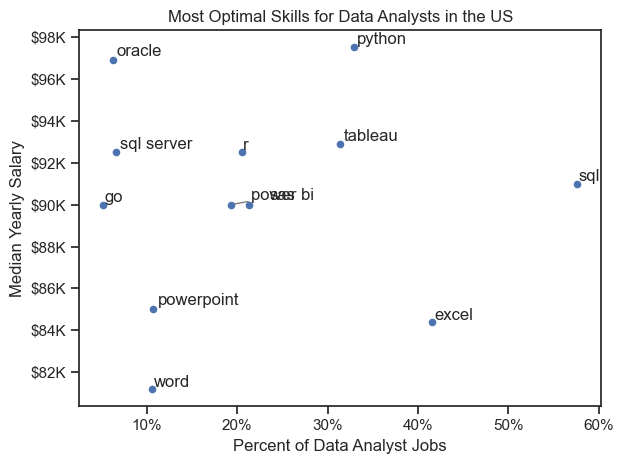

In [6]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind='scatter', x='skill_perc', y='median_salary')

texts = []
for i, text in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_perc'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], text))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='grey', lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()

In [7]:
df['job_type_skills'].head(10)

0                                                 None
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5    {'cloud': ['gcp'], 'programming': ['python', '...
6    {'cloud': ['gcp', 'bigquery'], 'databases': ['...
7    {'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...
8    {'analyst_tools': ['excel', 'powerpoint', 'pow...
9    {'analyst_tools': ['excel'], 'cloud': ['azure'...
Name: job_type_skills, dtype: object

In [8]:
import ast

df_technology = df['job_type_skills'].copy()

df_technology = df_technology.drop_duplicates()

df_technology = df_technology.dropna()

technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict: 
            technology_dict[key] += value
        else:                     
            technology_dict[key] = value

for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['sharepoint',
  'visio',
  'power bi',
  'outlook',
  'ms access',
  'alteryx',
  'nuix',
  'spss',
  'esquisse',
  'word',
  'powerbi',
  'excel',
  'sas',
  'datarobot',
  'powerpoint',
  'looker',
  'qlik',
  'microstrategy',
  'ssrs',
  'tableau',
  'sheets',
  'spreadsheet',
  'ssis',
  'splunk',
  'cognos',
  'msaccess',
  'sap',
  'dax'],
 'programming': ['rust',
  'go',
  'crystal',
  'visualbasic',
  'scala',
  'vb.net',
  'c#',
  'ruby',
  'erlang',
  'ocaml',
  'mongodb',
  'golang',
  'sql',
  'swift',
  'f#',
  'dart',
  'vba',
  'java',
  'typescript',
  'javascript',
  'julia',
  'no-sql',
  'css',
  'matlab',
  'pascal',
  'sas',
  'assembly',
  'elixir',
  'powershell',
  'delphi',
  'fortran',
  'solidity',
  'haskell',
  'nosql',
  'groovy',
  'html',
  'r',
  'shell',
  't-sql',
  'objective-c',
  'clojure',
  'mongo',
  'php',
  'c',
  'lisp',
  'c++',
  'kotlin',
  'cobol',
  'bash',
  'perl',
  'sass',
  'visual basic',
  'lua',
  'python',
  '

In [9]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,sharepoint
0,analyst_tools,visio
0,analyst_tools,power bi
0,analyst_tools,outlook
0,analyst_tools,ms access
...,...,...
9,sync,symphony
9,sync,webex
9,sync,twilio
9,sync,google chat


In [10]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

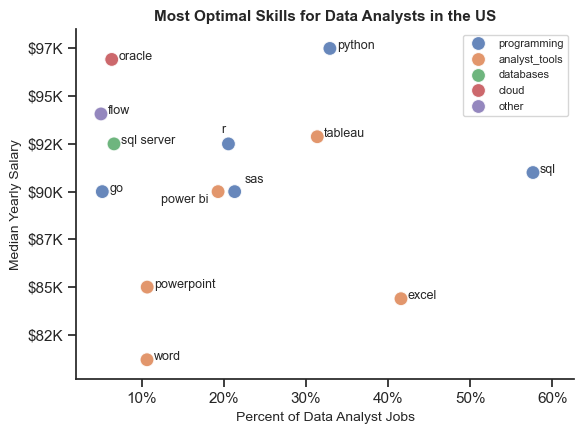

In [26]:
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="ticks")
plt.figure(figsize=(6, 4.5))

df_plot = df_DA_skills.sort_values(by="skill_count", ascending=False).head(13)

sns.scatterplot(
    data=df_plot,
    x="skill_perc",
    y="median_salary",
    hue="technology",
    s=100,
    alpha=0.85,
)
sns.despine()

for i, text in enumerate(df_plot.index):
    x_val = df_plot["skill_perc"].iloc[i]
    y_val = df_plot["median_salary"].iloc[i]

    if text == "power bi":
        plt.annotate(text, (x_val, y_val), textcoords="offset points", xytext=(-7, -2), ha="right", va="top", fontsize=9)
    elif text == "sas":
        plt.annotate(text, (x_val, y_val), textcoords="offset points", xytext=(7, 4), ha="left", va="bottom", fontsize=9)
    elif text == "r":
        plt.annotate(text, (x_val, y_val), textcoords="offset points", xytext=(-2, 6), ha="right", va="bottom", fontsize=9)
    else:
        plt.annotate(text, (x_val, y_val), textcoords="offset points", xytext=(5, 2), ha="left", va="center", fontsize=9)

plt.xlim(df_plot["skill_perc"].min() - 3, df_plot["skill_perc"].max() + 5)
plt.ylim(df_plot["median_salary"].min() - 1000, df_plot["median_salary"].max() + 1000)

plt.xlabel("Percent of Data Analyst Jobs", fontsize=10)
plt.ylabel("Median Yearly Salary", fontsize=10)
plt.title("Most Optimal Skills for Data Analysts in the US", fontsize=11, fontweight="bold")

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y/1000)}K"))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.legend(loc="upper right", frameon=True, fontsize=8)

plt.tight_layout()
plt.show()